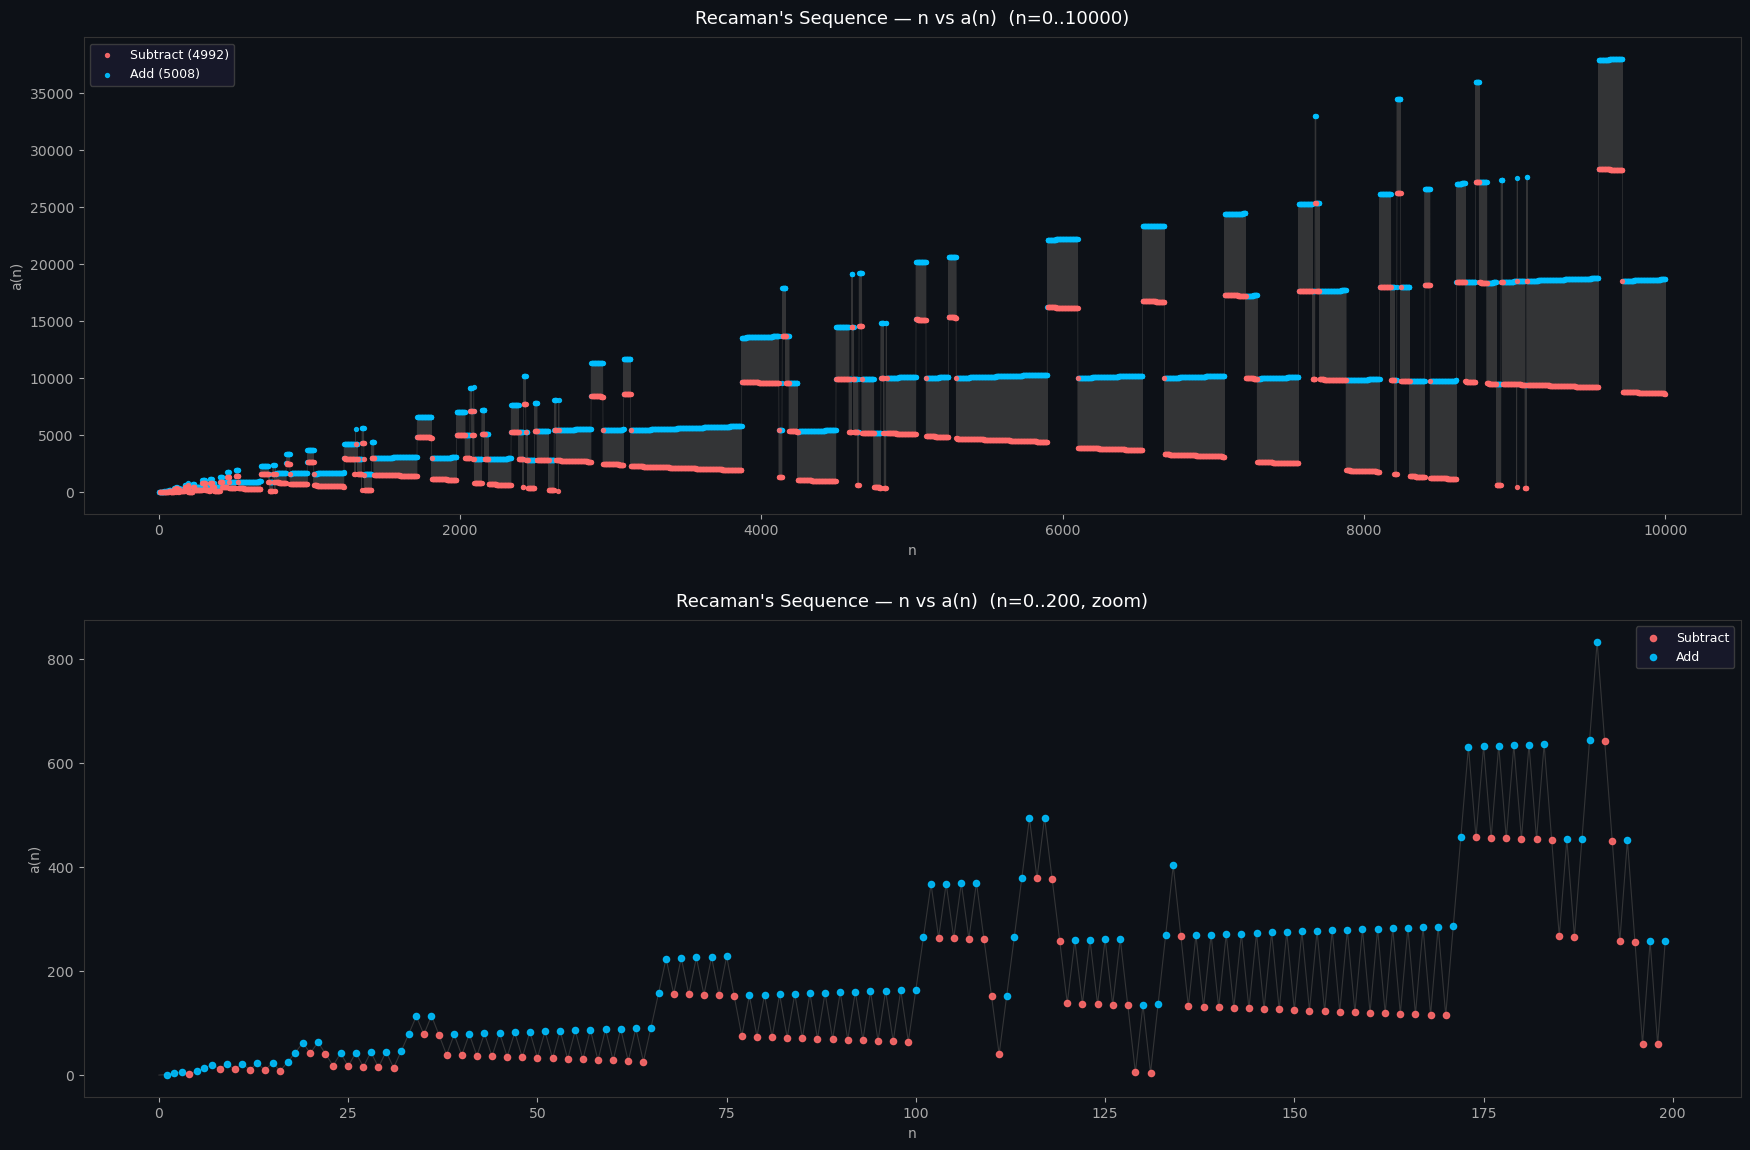

First 20 terms: [0, 1, 3, 6, 2, 7, 13, 20, 12, 21, 11, 22, 10, 23, 9, 24, 8, 25, 43, 62]
a(10000) = 18658
Max value: 37947
Unique values: 7741
Subtract: 4992  Add: 5008


In [1]:
import matplotlib.pyplot as plt
import numpy as np

def recaman(n_max):
    seq = [0]
    seen = {0}
    for n in range(1, n_max + 1):
        prev = seq[-1]
        candidate = prev - n
        if candidate > 0 and candidate not in seen:
            seq.append(candidate)
        else:
            seq.append(prev + n)
        seen.add(seq[-1])
    return seq

seq = recaman(10000)

add_idx      = [n for n in range(1, len(seq)) if seq[n] > seq[n-1]]
subtract_idx = [n for n in range(1, len(seq)) if seq[n] < seq[n-1]]

fig, axes = plt.subplots(2, 1, figsize=(18, 12))
fig.patch.set_facecolor('#0d1117')

# --- Plot 1: n vs a(n)  all 10000 terms ---
ax1 = axes[0]
ax1.set_facecolor('#0d1117')
ax1.set_title("Recaman's Sequence — n vs a(n)  (n=0..10000)", color='white', fontsize=13, pad=10)

ax1.plot(range(len(seq)), seq, color='#444', lw=0.5, alpha=0.7, zorder=1)
ax1.scatter(subtract_idx, [seq[i] for i in subtract_idx],
            s=8, color='#ff6b6b', alpha=0.9, label=f'Subtract ({len(subtract_idx)})', zorder=3)
ax1.scatter(add_idx, [seq[i] for i in add_idx],
            s=8, color='#00bfff', alpha=0.9, label=f'Add ({len(add_idx)})', zorder=2)

ax1.set_xlabel('n', color='#aaa', fontsize=10)
ax1.set_ylabel('a(n)', color='#aaa', fontsize=10)
ax1.tick_params(colors='#aaa')
ax1.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white', fontsize=9)
for spine in ax1.spines.values():
    spine.set_edgecolor('#333')

# --- Plot 2: n vs a(n)  first 200 terms (zoom) ---
ax2 = axes[1]
ax2.set_facecolor('#0d1117')
ax2.set_title("Recaman's Sequence — n vs a(n)  (n=0..200, zoom)", color='white', fontsize=13, pad=10)

zoom = 200
s_z = [i for i in subtract_idx if i < zoom]
a_z = [i for i in add_idx      if i < zoom]

ax2.plot(range(zoom), seq[:zoom], color='#444', lw=0.8, alpha=0.7, zorder=1)
ax2.scatter(s_z, [seq[i] for i in s_z],
            s=20, color='#ff6b6b', alpha=0.9, label='Subtract', zorder=3)
ax2.scatter(a_z, [seq[i] for i in a_z],
            s=20, color='#00bfff', alpha=0.9, label='Add', zorder=2)

ax2.set_xlabel('n', color='#aaa', fontsize=10)
ax2.set_ylabel('a(n)', color='#aaa', fontsize=10)
ax2.tick_params(colors='#aaa')
ax2.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white', fontsize=9)
for spine in ax2.spines.values():
    spine.set_edgecolor('#333')

plt.tight_layout(pad=2.5)
plt.savefig("recaman_original.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"First 20 terms: {seq[:20]}")
print(f"a(10000) = {seq[10000]}")
print(f"Max value: {max(seq)}")
print(f"Unique values: {len(set(seq))}")
print(f"Subtract: {len(subtract_idx)}  Add: {len(add_idx)}")


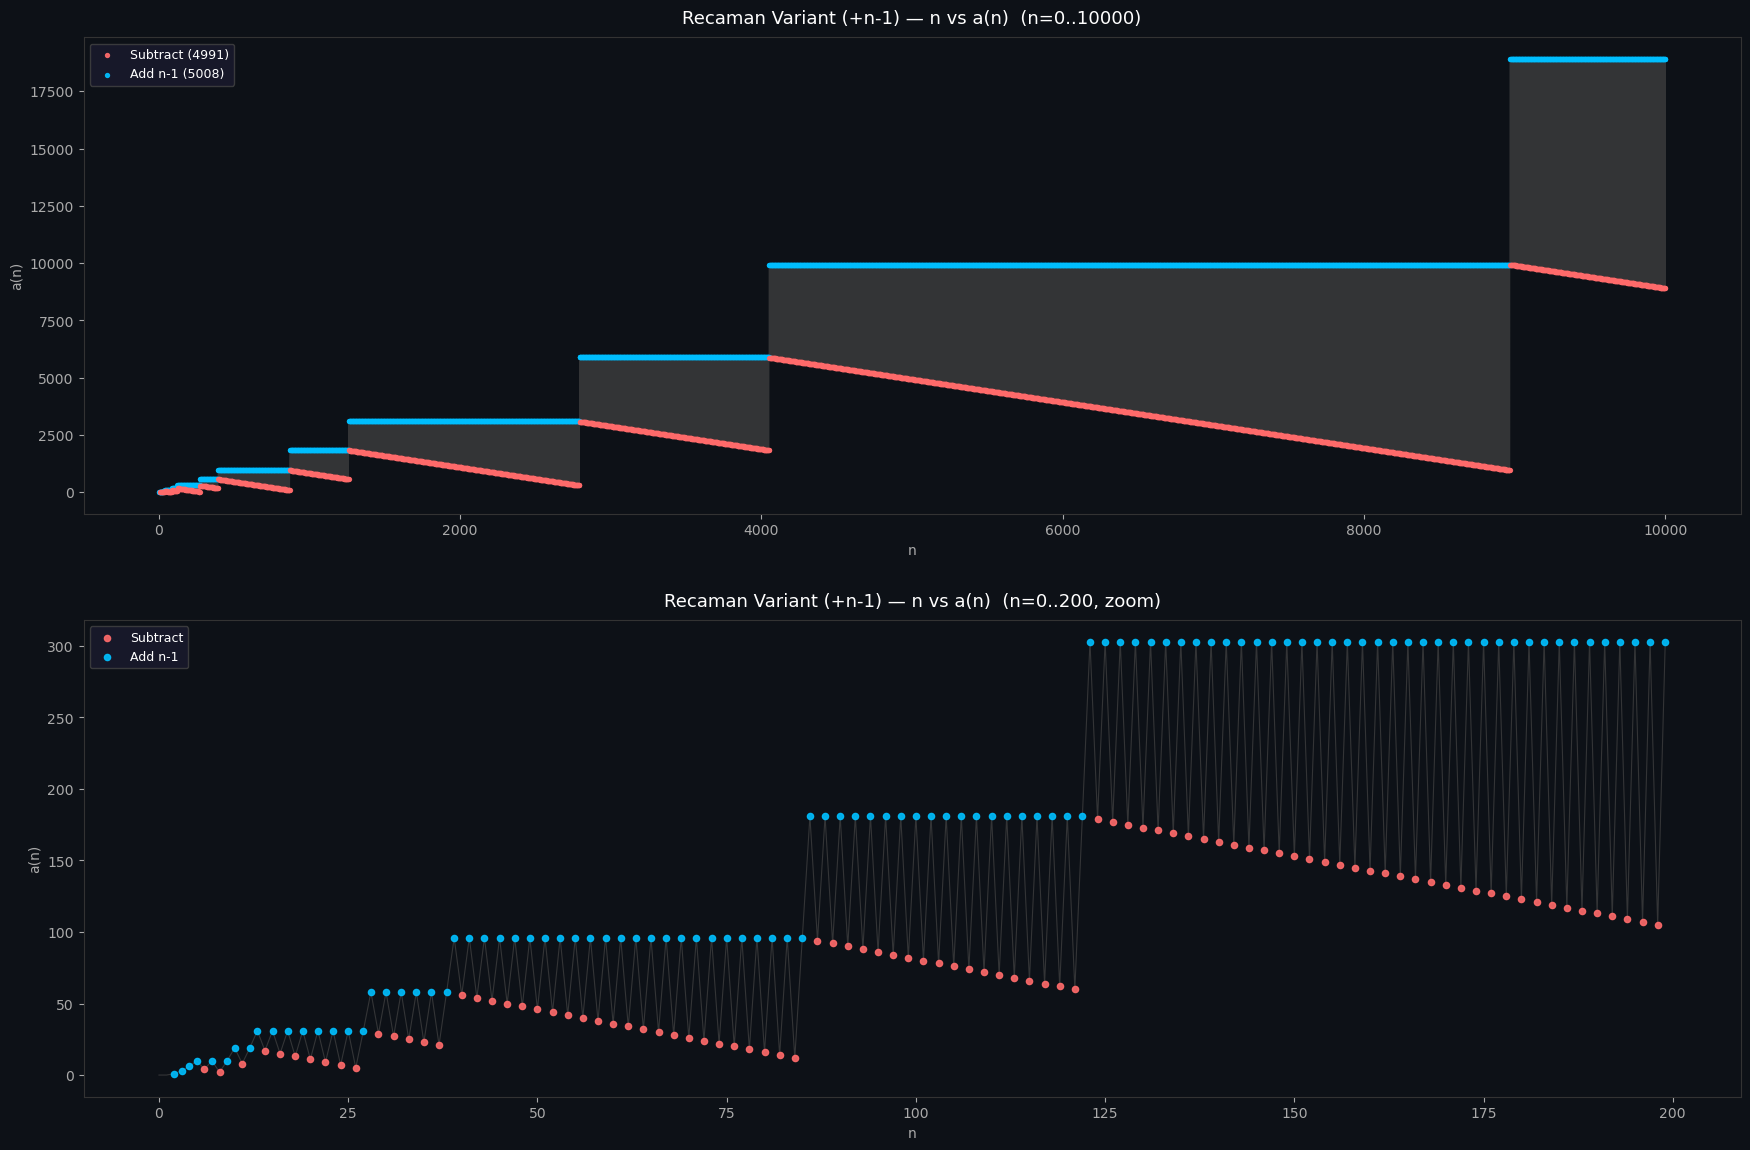

First 20 terms: [0, 0, 1, 3, 6, 10, 4, 10, 2, 10, 19, 8, 19, 31, 17, 31, 15, 31, 13, 31]
a(10000) = 18905
Max value: 18905
Unique values: 5009
Subtract: 4991  Add(n-1): 5008


In [2]:
import matplotlib.pyplot as plt
import numpy as np

def recaman_plus_nm1(n_max):
    seq = [0]
    seen = {0}
    for n in range(1, n_max + 1):
        prev = seq[-1]
        candidate = prev - n
        if candidate > 0 and candidate not in seen:
            seq.append(candidate)
        else:
            seq.append(prev + n - 1)
        seen.add(seq[-1])
    return seq

seq = recaman_plus_nm1(10000)

add_idx      = [n for n in range(1, len(seq)) if seq[n] > seq[n-1]]
subtract_idx = [n for n in range(1, len(seq)) if seq[n] < seq[n-1]]

fig, axes = plt.subplots(2, 1, figsize=(18, 12))
fig.patch.set_facecolor('#0d1117')

# --- Plot 1: n vs a(n)  all 10000 terms ---
ax1 = axes[0]
ax1.set_facecolor('#0d1117')
ax1.set_title("Recaman Variant (+n-1) — n vs a(n)  (n=0..10000)", color='white', fontsize=13, pad=10)

ax1.plot(range(len(seq)), seq, color='#444', lw=0.5, alpha=0.7, zorder=1)
ax1.scatter(subtract_idx, [seq[i] for i in subtract_idx],
            s=8, color='#ff6b6b', alpha=0.9, label=f'Subtract ({len(subtract_idx)})', zorder=3)
ax1.scatter(add_idx, [seq[i] for i in add_idx],
            s=8, color='#00bfff', alpha=0.9, label=f'Add n-1 ({len(add_idx)})', zorder=2)

ax1.set_xlabel('n', color='#aaa', fontsize=10)
ax1.set_ylabel('a(n)', color='#aaa', fontsize=10)
ax1.tick_params(colors='#aaa')
ax1.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white', fontsize=9)
for spine in ax1.spines.values():
    spine.set_edgecolor('#333')

# --- Plot 2: n vs a(n)  first 200 terms (zoom) ---
ax2 = axes[1]
ax2.set_facecolor('#0d1117')
ax2.set_title("Recaman Variant (+n-1) — n vs a(n)  (n=0..200, zoom)", color='white', fontsize=13, pad=10)

zoom = 200
s_z = [i for i in subtract_idx if i < zoom]
a_z = [i for i in add_idx      if i < zoom]

ax2.plot(range(zoom), seq[:zoom], color='#444', lw=0.8, alpha=0.7, zorder=1)
ax2.scatter(s_z, [seq[i] for i in s_z],
            s=20, color='#ff6b6b', alpha=0.9, label='Subtract', zorder=3)
ax2.scatter(a_z, [seq[i] for i in a_z],
            s=20, color='#00bfff', alpha=0.9, label='Add n-1', zorder=2)

ax2.set_xlabel('n', color='#aaa', fontsize=10)
ax2.set_ylabel('a(n)', color='#aaa', fontsize=10)
ax2.tick_params(colors='#aaa')
ax2.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white', fontsize=9)
for spine in ax2.spines.values():
    spine.set_edgecolor('#333')

plt.tight_layout(pad=2.5)
plt.savefig("recaman_plus_nm1.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"First 20 terms: {seq[:20]}")
print(f"a(10000) = {seq[10000]}")
print(f"Max value: {max(seq)}")
print(f"Unique values: {len(set(seq))}")
print(f"Subtract: {len(subtract_idx)}  Add(n-1): {len(add_idx)}")


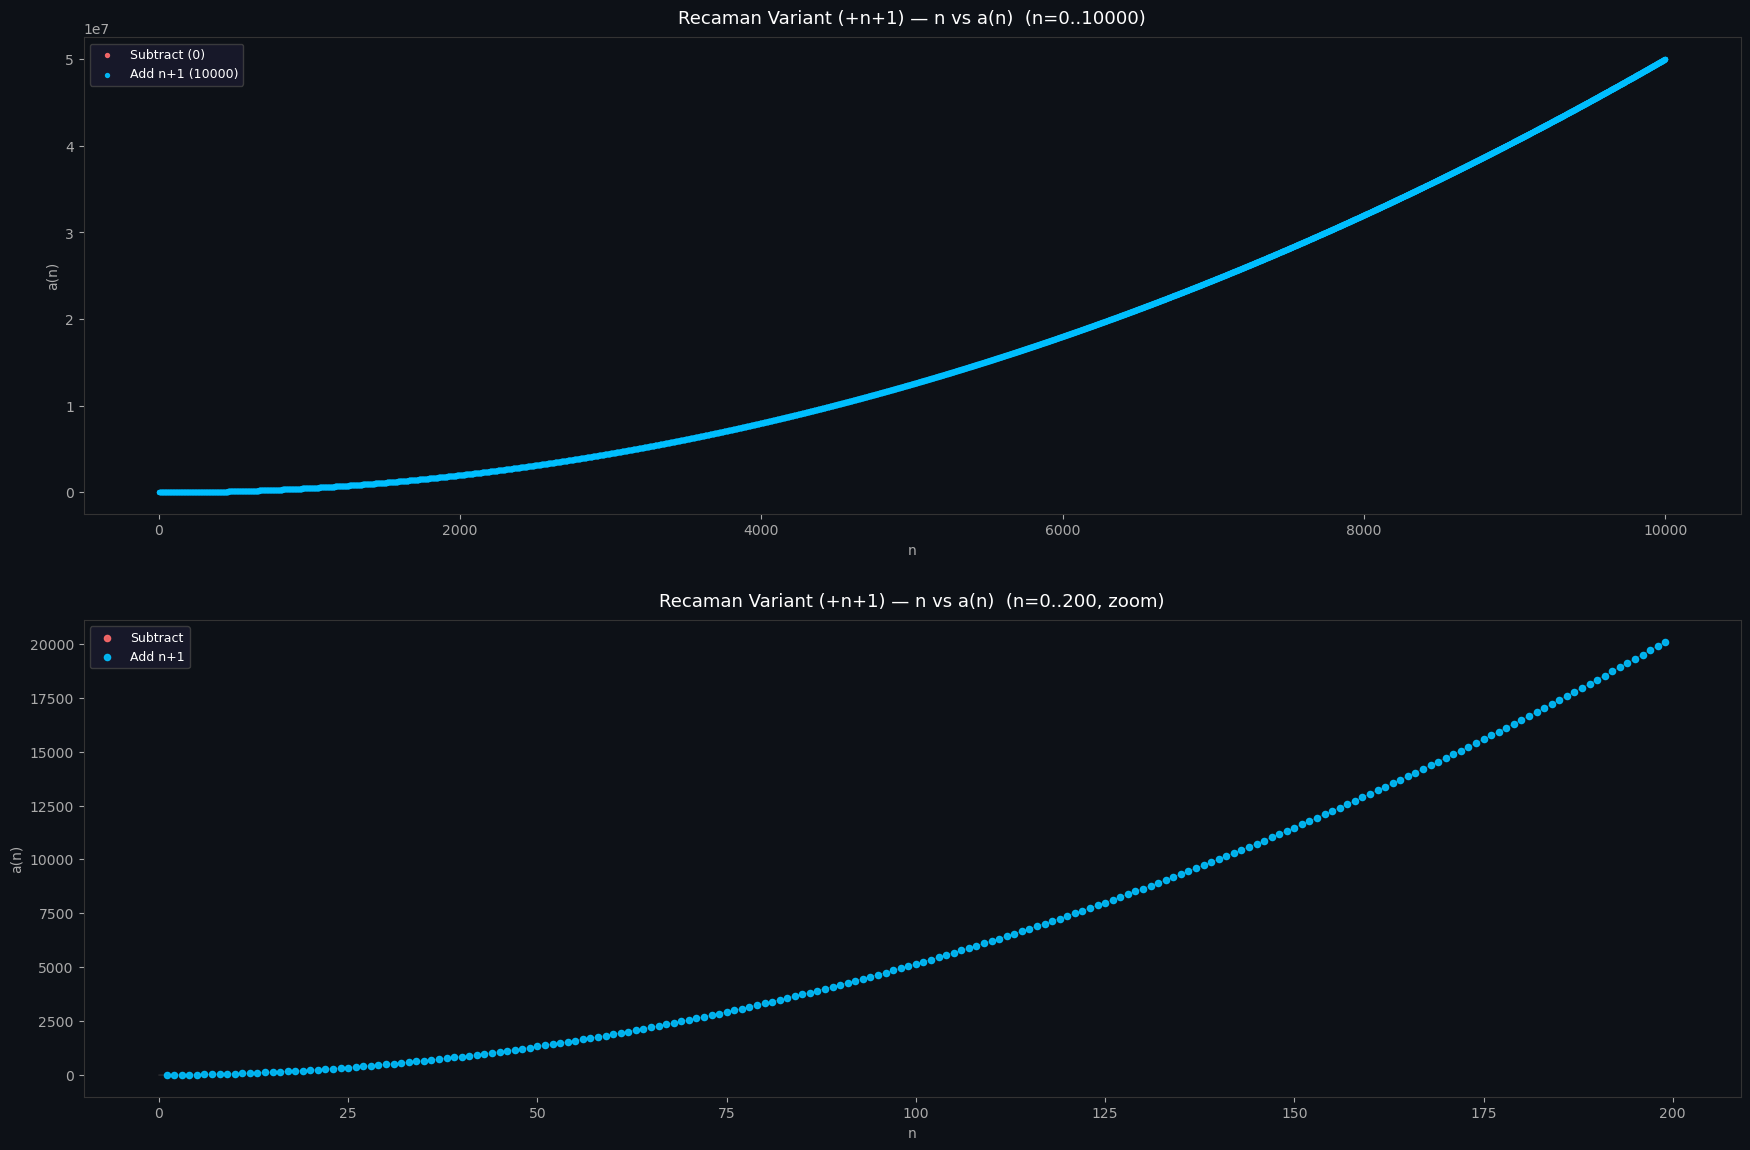

First 20 terms: [0, 2, 5, 9, 14, 20, 27, 35, 44, 54, 65, 77, 90, 104, 119, 135, 152, 170, 189, 209]
a(10000) = 50015000
Max value: 50015000
Unique values: 10001
Subtract: 0  Add(n+1): 10000


In [3]:
import matplotlib.pyplot as plt
import numpy as np

def recaman_plus_np1(n_max):
    seq = [0]
    seen = {0}
    for n in range(1, n_max + 1):
        prev = seq[-1]
        candidate = prev - n
        if candidate > 0 and candidate not in seen:
            seq.append(candidate)
        else:
            seq.append(prev + n + 1)
        seen.add(seq[-1])
    return seq

seq = recaman_plus_np1(10000)

add_idx      = [n for n in range(1, len(seq)) if seq[n] > seq[n-1]]
subtract_idx = [n for n in range(1, len(seq)) if seq[n] < seq[n-1]]

fig, axes = plt.subplots(2, 1, figsize=(18, 12))
fig.patch.set_facecolor('#0d1117')

# --- Plot 1: n vs a(n)  all 10000 terms ---
ax1 = axes[0]
ax1.set_facecolor('#0d1117')
ax1.set_title("Recaman Variant (+n+1) — n vs a(n)  (n=0..10000)", color='white', fontsize=13, pad=10)

ax1.plot(range(len(seq)), seq, color='#444', lw=0.5, alpha=0.7, zorder=1)
ax1.scatter(subtract_idx, [seq[i] for i in subtract_idx],
            s=8, color='#ff6b6b', alpha=0.9, label=f'Subtract ({len(subtract_idx)})', zorder=3)
ax1.scatter(add_idx, [seq[i] for i in add_idx],
            s=8, color='#00bfff', alpha=0.9, label=f'Add n+1 ({len(add_idx)})', zorder=2)

ax1.set_xlabel('n', color='#aaa', fontsize=10)
ax1.set_ylabel('a(n)', color='#aaa', fontsize=10)
ax1.tick_params(colors='#aaa')
ax1.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white', fontsize=9)
for spine in ax1.spines.values():
    spine.set_edgecolor('#333')

# --- Plot 2: n vs a(n)  first 200 terms (zoom) ---
ax2 = axes[1]
ax2.set_facecolor('#0d1117')
ax2.set_title("Recaman Variant (+n+1) — n vs a(n)  (n=0..200, zoom)", color='white', fontsize=13, pad=10)

zoom = 200
s_z = [i for i in subtract_idx if i < zoom]
a_z = [i for i in add_idx      if i < zoom]

ax2.plot(range(zoom), seq[:zoom], color='#444', lw=0.8, alpha=0.7, zorder=1)
ax2.scatter(s_z, [seq[i] for i in s_z],
            s=20, color='#ff6b6b', alpha=0.9, label='Subtract', zorder=3)
ax2.scatter(a_z, [seq[i] for i in a_z],
            s=20, color='#00bfff', alpha=0.9, label='Add n+1', zorder=2)

ax2.set_xlabel('n', color='#aaa', fontsize=10)
ax2.set_ylabel('a(n)', color='#aaa', fontsize=10)
ax2.tick_params(colors='#aaa')
ax2.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white', fontsize=9)
for spine in ax2.spines.values():
    spine.set_edgecolor('#333')

plt.tight_layout(pad=2.5)
plt.savefig("recaman_plus_np1.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"First 20 terms: {seq[:20]}")
print(f"a(10000) = {seq[10000]}")
print(f"Max value: {max(seq)}")
print(f"Unique values: {len(set(seq))}")
print(f"Subtract: {len(subtract_idx)}  Add(n+1): {len(add_idx)}")


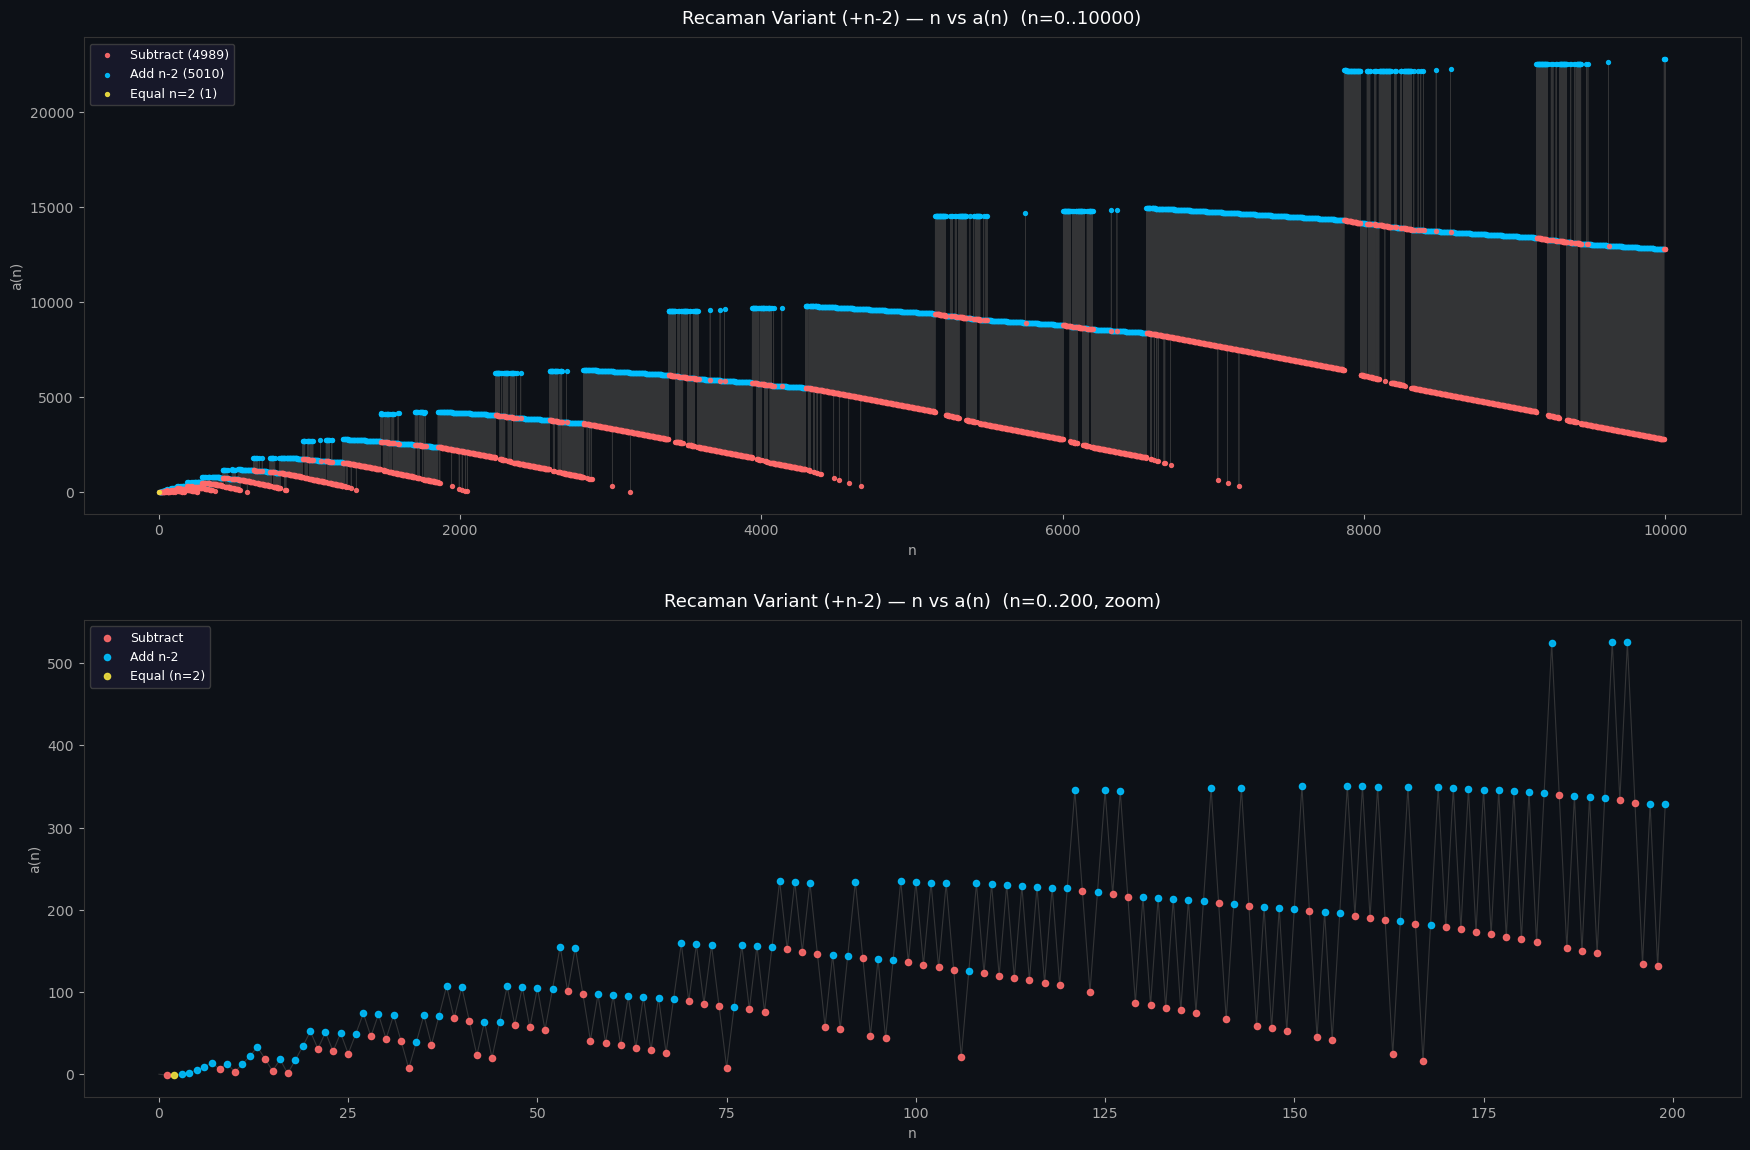

First 20 terms: [0, -1, -1, 0, 2, 5, 9, 14, 6, 13, 3, 12, 22, 33, 19, 4, 18, 1, 17, 34]
a(10000) = 12768
Max value: 22771
Unique values: 9308
Subtract: 4989  Add(n-2): 5010  Equal: 1


In [4]:
import matplotlib.pyplot as plt
import numpy as np

def recaman_plus_nm2(n_max):
    seq = [0]
    seen = {0}
    for n in range(1, n_max + 1):
        prev = seq[-1]
        candidate = prev - n
        if candidate > 0 and candidate not in seen:
            seq.append(candidate)
        else:
            seq.append(prev + n - 2)
        seen.add(seq[-1])
    return seq

seq = recaman_plus_nm2(10000)

add_idx      = [n for n in range(1, len(seq)) if seq[n] > seq[n-1]]
subtract_idx = [n for n in range(1, len(seq)) if seq[n] < seq[n-1]]
equal_idx    = [n for n in range(1, len(seq)) if seq[n] == seq[n-1]]

fig, axes = plt.subplots(2, 1, figsize=(18, 12))
fig.patch.set_facecolor('#0d1117')

# --- Plot 1: n vs a(n)  all 10000 terms ---
ax1 = axes[0]
ax1.set_facecolor('#0d1117')
ax1.set_title("Recaman Variant (+n-2) — n vs a(n)  (n=0..10000)", color='white', fontsize=13, pad=10)

ax1.plot(range(len(seq)), seq, color='#444', lw=0.5, alpha=0.7, zorder=1)
ax1.scatter(subtract_idx, [seq[i] for i in subtract_idx],
            s=8, color='#ff6b6b', alpha=0.9, label=f'Subtract ({len(subtract_idx)})', zorder=3)
ax1.scatter(add_idx, [seq[i] for i in add_idx],
            s=8, color='#00bfff', alpha=0.9, label=f'Add n-2 ({len(add_idx)})', zorder=2)
if equal_idx:
    ax1.scatter(equal_idx, [seq[i] for i in equal_idx],
                s=8, color='#f0e040', alpha=0.9, label=f'Equal n=2 ({len(equal_idx)})', zorder=4)

ax1.set_xlabel('n', color='#aaa', fontsize=10)
ax1.set_ylabel('a(n)', color='#aaa', fontsize=10)
ax1.tick_params(colors='#aaa')
ax1.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white', fontsize=9)
for spine in ax1.spines.values():
    spine.set_edgecolor('#333')

# --- Plot 2: n vs a(n)  first 200 terms (zoom) ---
ax2 = axes[1]
ax2.set_facecolor('#0d1117')
ax2.set_title("Recaman Variant (+n-2) — n vs a(n)  (n=0..200, zoom)", color='white', fontsize=13, pad=10)

zoom = 200
s_z = [i for i in subtract_idx if i < zoom]
a_z = [i for i in add_idx      if i < zoom]
e_z = [i for i in equal_idx    if i < zoom]

ax2.plot(range(zoom), seq[:zoom], color='#444', lw=0.8, alpha=0.7, zorder=1)
ax2.scatter(s_z, [seq[i] for i in s_z],
            s=20, color='#ff6b6b', alpha=0.9, label='Subtract', zorder=3)
ax2.scatter(a_z, [seq[i] for i in a_z],
            s=20, color='#00bfff', alpha=0.9, label='Add n-2', zorder=2)
if e_z:
    ax2.scatter(e_z, [seq[i] for i in e_z],
                s=20, color='#f0e040', alpha=0.9, label='Equal (n=2)', zorder=4)

ax2.set_xlabel('n', color='#aaa', fontsize=10)
ax2.set_ylabel('a(n)', color='#aaa', fontsize=10)
ax2.tick_params(colors='#aaa')
ax2.legend(facecolor='#1a1a2e', edgecolor='#444', labelcolor='white', fontsize=9)
for spine in ax2.spines.values():
    spine.set_edgecolor('#333')

plt.tight_layout(pad=2.5)
plt.savefig("recaman_plus_nm2.png", dpi=150, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"First 20 terms: {seq[:20]}")
print(f"a(10000) = {seq[10000]}")
print(f"Max value: {max(seq)}")
print(f"Unique values: {len(set(seq))}")
print(f"Subtract: {len(subtract_idx)}  Add(n-2): {len(add_idx)}  Equal: {len(equal_idx)}")
